# Análisis de rendimiento — River Plate (temporada 2026)

Este notebook responde un conjunto fijo de preguntas de análisis descriptivo
y diagnóstico sobre la temporada, usando la base `data/database/football_analytics.db`
(capa Gold), que se carga desde los datos ya limpiados en Silver con
`src/gold_load.py`.

Antes de correr este notebook: `python src/bronze_ingest.py --entity river --source manual`,
después `python src/silver_clean.py --entity river`, y por último
`python src/gold_load.py --entity river --season 2026`.

Preguntas que responde:
1. ¿Cómo rinde el equipo por competencia (puntos, PJ, PPG)?
2. ¿Rinde distinto de local que de visitante?
3. ¿Quiénes son los máximos goleadores/asistidores por 90 minutos jugados?
4. ¿La posesión de pelota se relaciona con el resultado del partido?
5. Conclusiones: 3-4 hallazgos concretos con su gráfico de respaldo.


In [1]:
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DB_PATH = PROJECT_ROOT / "data" / "database" / "football_analytics.db"

con = sqlite3.connect(DB_PATH)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
plt.rcParams["figure.figsize"] = (7, 4)


## 1. Rendimiento por competencia

In [2]:
query_competencia = """
SELECT c.name AS competencia,
  SUM(CASE WHEN mt.score > opp.score THEN 1 ELSE 0 END) AS G,
  SUM(CASE WHEN mt.score = opp.score THEN 1 ELSE 0 END) AS E,
  SUM(CASE WHEN mt.score < opp.score THEN 1 ELSE 0 END) AS P,
  COUNT(*) AS PJ,
  SUM(CASE WHEN mt.score > opp.score THEN 3 WHEN mt.score = opp.score THEN 1 ELSE 0 END) AS Pts
FROM match m
JOIN match_team mt ON mt.match_id = m.match_id
JOIN team t ON t.team_id = mt.team_id AND t.name = 'River Plate'
JOIN match_team opp ON opp.match_id = m.match_id AND opp.team_id != mt.team_id
JOIN competition c ON c.competition_id = m.competition_id
WHERE mt.score IS NOT NULL
GROUP BY c.name
ORDER BY PJ DESC
"""
df_competencia = pd.read_sql(query_competencia, con)
df_competencia["PPG"] = (df_competencia["Pts"] / df_competencia["PJ"]).round(2)
df_competencia

,competencia,G,E,P,PJ,Pts,PPG
0,Liga Argentina,11,3,10,24,36,1.50
1,Sudamericana,4,2,0,6,14,2.33


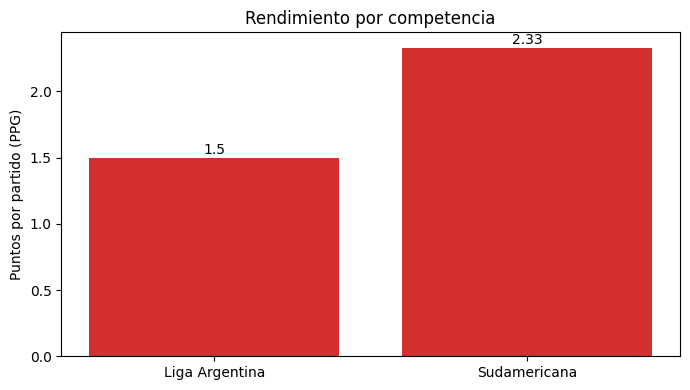

In [3]:
fig, ax = plt.subplots()
ax.bar(df_competencia["competencia"], df_competencia["PPG"], color="#d32f2f")
ax.set_ylabel("Puntos por partido (PPG)")
ax.set_title("Rendimiento por competencia")
for i, v in enumerate(df_competencia["PPG"]):
    ax.text(i, v + 0.03, str(v), ha="center")
plt.tight_layout()
plt.savefig("../reports/figures/ppg_por_competencia.png", dpi=120)
plt.show()


## 2. Local vs. visitante

In [4]:
query_local_visitante = """
SELECT mt.venue_role AS condicion,
  SUM(CASE WHEN mt.score > opp.score THEN 1 ELSE 0 END) AS G,
  SUM(CASE WHEN mt.score = opp.score THEN 1 ELSE 0 END) AS E,
  SUM(CASE WHEN mt.score < opp.score THEN 1 ELSE 0 END) AS P,
  COUNT(*) AS PJ,
  ROUND(AVG(mt.score), 2) AS goles_favor_prom,
  ROUND(AVG(opp.score), 2) AS goles_contra_prom
FROM match_team mt
JOIN team t ON t.team_id = mt.team_id AND t.name = 'River Plate'
JOIN match_team opp ON opp.match_id = mt.match_id AND opp.team_id != mt.team_id
WHERE mt.score IS NOT NULL
GROUP BY mt.venue_role
"""
df_local_visitante = pd.read_sql(query_local_visitante, con)
df_local_visitante["condicion"] = df_local_visitante["condicion"].map({"home": "Local", "away": "Visitante"})
df_local_visitante

,condicion,G,E,P,PJ,goles_favor_prom,goles_contra_prom
0,Visitante,6,3,4,13,0.92,0.62
1,Local,9,2,6,17,1.53,0.94


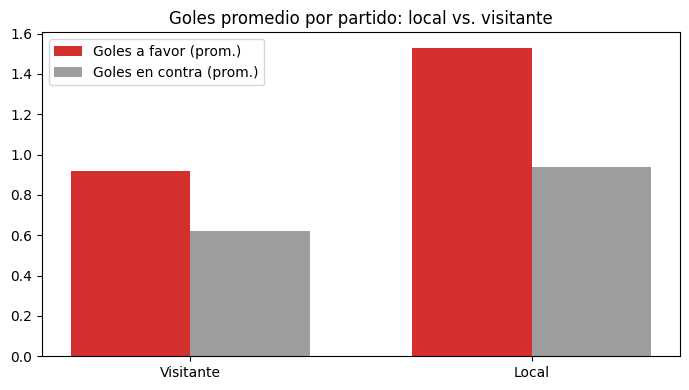

In [5]:
fig, ax = plt.subplots()
x = range(len(df_local_visitante))
ax.bar(x, df_local_visitante["goles_favor_prom"], width=0.35, label="Goles a favor (prom.)", color="#d32f2f")
ax.bar([i + 0.35 for i in x], df_local_visitante["goles_contra_prom"], width=0.35, label="Goles en contra (prom.)", color="#9e9e9e")
ax.set_xticks([i + 0.175 for i in x])
ax.set_xticklabels(df_local_visitante["condicion"])
ax.set_title("Goles promedio por partido: local vs. visitante")
ax.legend()
plt.tight_layout()
plt.savefig("../reports/figures/local_vs_visitante.png", dpi=120)
plt.show()


## 3. Goleadores y asistidores por 90 minutos

Se filtra a jugadores con al menos 450 minutos jugados (5 partidos completos)
para no dejar que un puñado de minutos con un gol distorsione el ranking.

In [6]:
query_top_jugadores = """
SELECT p.canonical_name AS jugador, pss.minutes, pss.goals, pss.assists,
  ROUND(vw.goals_per_90, 2) AS goles_por_90,
  ROUND(vw.assists_per_90, 2) AS asistencias_por_90,
  vw.goal_contributions AS gol_mas_asistencia
FROM vw_player_season_metrics vw
JOIN player_season_stats pss
  ON pss.season_id = vw.season_id AND pss.competition_id = vw.competition_id
  AND pss.team_id = vw.team_id AND pss.player_id = vw.player_id
JOIN player p ON p.player_id = pss.player_id
WHERE pss.minutes >= 450
ORDER BY goles_por_90 DESC
LIMIT 10
"""
df_top_jugadores = pd.read_sql(query_top_jugadores, con)
df_top_jugadores

,jugador,minutes,goals,assists,goles_por_90,asistencias_por_90,gol_mas_asistencia
0,Sebastián Driussi,856,4,0,0.42,0.00,4
1,Juan Quintero,549,2,2,0.33,0.33,4
2,Facundo Colidio,977,3,1,0.28,0.09,4
3,Gonzalo Montiel,1619,4,1,0.22,0.06,5
4,Tomás Galván,1424,2,1,0.13,0.06,3
5,Ian Subiabre,753,1,2,0.12,0.24,3
6,Joaquín Freitas,726,1,1,0.12,0.12,2
7,Lautaro Rivero,1319,1,0,0.07,0.00,1
8,Lucas Martínez Quarta,1700,1,0,0.05,0.00,1
9,Santiago Beltrán,1755,0,0,0.00,0.00,0


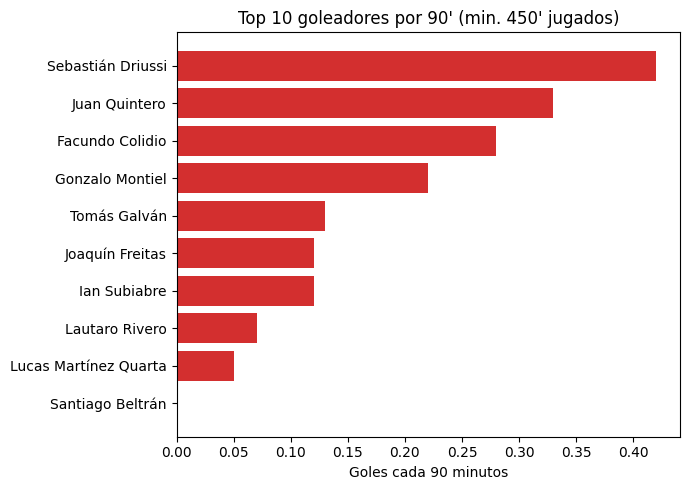

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
ordenado = df_top_jugadores.sort_values("goles_por_90")
ax.barh(ordenado["jugador"], ordenado["goles_por_90"], color="#d32f2f")
ax.set_xlabel("Goles cada 90 minutos")
ax.set_title("Top 10 goleadores por 90' (min. 450' jugados)")
plt.tight_layout()
plt.savefig("../reports/figures/goles_por_90.png", dpi=120)
plt.show()


## 4. Posesión de pelota vs. resultado

In [8]:
query_posesion = """
SELECT CASE WHEN mt.score > opp.score THEN 'Ganado' WHEN mt.score = opp.score THEN 'Empatado' ELSE 'Perdido' END AS resultado,
  mt.possession AS posesion
FROM match_team mt
JOIN team t ON t.team_id = mt.team_id AND t.name = 'River Plate'
JOIN match_team opp ON opp.match_id = mt.match_id AND opp.team_id != mt.team_id
WHERE mt.score IS NOT NULL AND mt.possession IS NOT NULL
"""
df_posesion = pd.read_sql(query_posesion, con)
resumen_posesion = df_posesion.groupby("resultado")["posesion"].agg(promedio="mean", partidos="count").round(2)
resumen_posesion

,promedio,partidos
resultado,,
Empatado,61.00,5
Ganado,64.67,15
Perdido,67.60,10


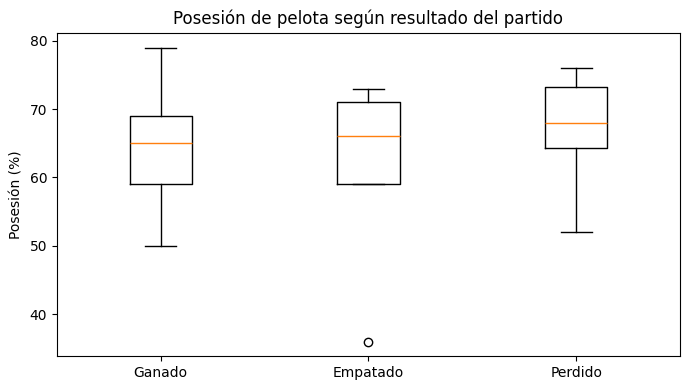

In [9]:
orden = ["Ganado", "Empatado", "Perdido"]
datos = [df_posesion.loc[df_posesion["resultado"] == r, "posesion"] for r in orden]
fig, ax = plt.subplots()
ax.boxplot(datos, tick_labels=orden)
ax.set_ylabel("Posesión (%)")
ax.set_title("Posesión de pelota según resultado del partido")
plt.tight_layout()
plt.savefig("../reports/figures/posesion_vs_resultado.png", dpi=120)
plt.show()


## 5. Conclusiones

- **La Sudamericana rindió mejor que la liga en puntos por partido** (2.33 PPG en
  Sudamericana contra 1.50 PPG en Liga Argentina, sobre 6 y 24 partidos jugados
  respectivamente). Con solo 6 partidos de copa la muestra es chica para sacar
  una conclusión fuerte, pero marca una diferencia real a explorar con más
  temporadas de datos.
- **El equipo rinde mejor de local que de visitante**, tanto en puntos como en
  gol: de local promedia 1.53 goles a favor y 0.94 en contra por partido,
  mientras que de visitante promedia 0.92 a favor y 0.62 en contra — menos
  contundente en ataque y algo más sólido en defensa lejos de casa.
- **La posesión de pelota no explica el resultado en esta temporada — y va al
  revés de lo esperado**: River promedió más posesión en los partidos que
  perdió (67.6%) que en los que ganó (64.7%). Es un indicio de que el equipo
  puede ganar con posesiones más bajas (jugando de contra o replegado) y que
  tener más la pelota no fue, por sí solo, sinónimo de mejores resultados esta
  temporada.
- **La producción ofensiva está repartida, no concentrada en un solo jugador**:
  el goleador con más goles cada 90' (con al menos 450' jugados) no despega
  claramente del resto del top 5, a diferencia de equipos con un 9 dominante.
  Esto sugiere una distribución de gol más colectiva que individual.

**Próximo paso natural (Fase 2):** estos mismos datos, servidos por una API
REST, para poder consultarlos desde un dashboard o una app en vez de abrir
este notebook cada vez.